In [53]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("wordsforthewise/lending-club")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'lending-club' dataset.
Path to dataset files: /kaggle/input/lending-club


In [54]:
import pandas as pd
import os
files = os.listdir(path)
print(files)


['rejected_2007_to_2018Q4.csv.gz', 'accepted_2007_to_2018Q4.csv.gz', 'accepted_2007_to_2018q4.csv', 'rejected_2007_to_2018q4.csv']


In [55]:
import pandas as pd
import os
use_cols = [
    'loan_status', 'emp_title', 'addr_state', 'issue_d',
    'loan_amnt', 'term', 'int_rate', 'installment',
    'grade', 'annual_inc', 'dti', 'delinq_2yrs',
    'fico_range_low', 'open_acc', 'revol_util',
    'pub_rec', 'purpose', 'home_ownership']

file_path = os.path.join(path, 'accepted_2007_to_2018Q4.csv.gz')
df= pd.read_csv(file_path,usecols=use_cols, low_memory=False)


In [56]:

df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 18 columns):
 #   Column          Dtype  
---  ------          -----  
 0   loan_amnt       float64
 1   term            object 
 2   int_rate        float64
 3   installment     float64
 4   grade           object 
 5   emp_title       object 
 6   home_ownership  object 
 7   annual_inc      float64
 8   issue_d         object 
 9   loan_status     object 
 10  purpose         object 
 11  addr_state      object 
 12  dti             float64
 13  delinq_2yrs     float64
 14  fico_range_low  float64
 15  open_acc        float64
 16  pub_rec         float64
 17  revol_util      float64
dtypes: float64(10), object(8)
memory usage: 1.1 GB


In [57]:
df.head()

,loan_amnt,term,int_rate,installment,grade,emp_title,home_ownership,annual_inc,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,fico_range_low,open_acc,pub_rec,revol_util
0,3600.0,36 months,13.99,123.03,C,leadman,MORTGAGE,55000.0,Dec-2015,Fully Paid,debt_consolidation,PA,5.91,0.0,675.0,7.0,0.0,29.7
1,24700.0,36 months,11.99,820.28,C,Engineer,MORTGAGE,65000.0,Dec-2015,Fully Paid,small_business,SD,16.06,1.0,715.0,22.0,0.0,19.2
2,20000.0,60 months,10.78,432.66,B,truck driver,MORTGAGE,63000.0,Dec-2015,Fully Paid,home_improvement,IL,10.78,0.0,695.0,6.0,0.0,56.2
3,35000.0,60 months,14.85,829.90,C,Information Systems Officer,MORTGAGE,110000.0,Dec-2015,Current,debt_consolidation,NJ,17.06,0.0,785.0,13.0,0.0,11.6
4,10400.0,60 months,22.45,289.91,F,Contract Specialist,MORTGAGE,104433.0,Dec-2015,Fully Paid,major_purchase,PA,25.37,1.0,695.0,12.0,0.0,64.5


In [58]:
df.describe()

,loan_amnt,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,open_acc,pub_rec,revol_util
count,2.260668e+06,2.260668e+06,2.260668e+06,2.260664e+06,2.258957e+06,2.260639e+06,2.260668e+06,2.260639e+06,2.260639e+06,2.258866e+06
mean,1.504693e+04,1.309283e+01,4.458068e+02,7.799243e+04,1.882420e+01,3.068792e-01,6.985882e+02,1.161240e+01,1.975278e-01,5.033770e+01
std,9.190245e+03,4.832138e+00,2.671735e+02,1.126962e+05,1.418333e+01,8.672303e-01,3.301038e+01,5.640861e+00,5.705150e-01,2.471307e+01
min,5.000000e+02,5.310000e+00,4.930000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,6.100000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.000000e+03,9.490000e+00,2.516500e+02,4.600000e+04,1.189000e+01,0.000000e+00,6.750000e+02,8.000000e+00,0.000000e+00,3.150000e+01
50%,1.290000e+04,1.262000e+01,3.779900e+02,6.500000e+04,1.784000e+01,0.000000e+00,6.900000e+02,1.100000e+01,0.000000e+00,5.030000e+01
75%,2.000000e+04,1.599000e+01,5.933200e+02,9.300000e+04,2.449000e+01,0.000000e+00,7.150000e+02,1.400000e+01,0.000000e+00,6.940000e+01
max,4.000000e+04,3.099000e+01,1.719830e+03,1.100000e+08,9.990000e+02,5.800000e+01,8.450000e+02,1.010000e+02,8.600000e+01,8.923000e+02


In [59]:
df.shape

(2260701, 18)

In [60]:
df.isnull().sum()

,0
loan_amnt,33
term,33
int_rate,33
installment,33
grade,33
emp_title,167002
home_ownership,33
annual_inc,37
issue_d,33
loan_status,33


In [61]:
df = df.dropna(subset=['loan_amnt'])

In [62]:
df.shape

(2260668, 18)

In [63]:
df.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
emp_title,166969
home_ownership,0
annual_inc,4
issue_d,0
loan_status,0


In [64]:
import numpy as np
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

In [65]:
df.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
emp_title,166969
home_ownership,0
annual_inc,0
issue_d,0
loan_status,0


In [66]:
df['emp_title'].value_counts()

,count
emp_title,
Teacher,38824
Manager,34298
Owner,21977
Registered Nurse,15867
Driver,14753
...,...
Sales / project manager,1
wallcoverings department,1
Servicer Oversight,1


In [67]:
df=df.dropna(subset=['emp_title']).reset_index(drop=True)

In [68]:
df.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
emp_title,0
home_ownership,0
annual_inc,0
issue_d,0
loan_status,0


In [69]:
df.head()

,loan_amnt,term,int_rate,installment,grade,emp_title,home_ownership,annual_inc,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,fico_range_low,open_acc,pub_rec,revol_util
0,3600.0,36 months,13.99,123.03,C,leadman,MORTGAGE,55000.0,Dec-2015,Fully Paid,debt_consolidation,PA,5.91,0.0,675.0,7.0,0.0,29.7
1,24700.0,36 months,11.99,820.28,C,Engineer,MORTGAGE,65000.0,Dec-2015,Fully Paid,small_business,SD,16.06,1.0,715.0,22.0,0.0,19.2
2,20000.0,60 months,10.78,432.66,B,truck driver,MORTGAGE,63000.0,Dec-2015,Fully Paid,home_improvement,IL,10.78,0.0,695.0,6.0,0.0,56.2
3,35000.0,60 months,14.85,829.90,C,Information Systems Officer,MORTGAGE,110000.0,Dec-2015,Current,debt_consolidation,NJ,17.06,0.0,785.0,13.0,0.0,11.6
4,10400.0,60 months,22.45,289.91,F,Contract Specialist,MORTGAGE,104433.0,Dec-2015,Fully Paid,major_purchase,PA,25.37,1.0,695.0,12.0,0.0,64.5


In [70]:
df['loan_amnt'].value_counts()

,count
loan_amnt,
10000.0,170206
20000.0,122504
15000.0,114693
12000.0,114323
35000.0,82731
...,...
750.0,1
950.0,1
725.0,1


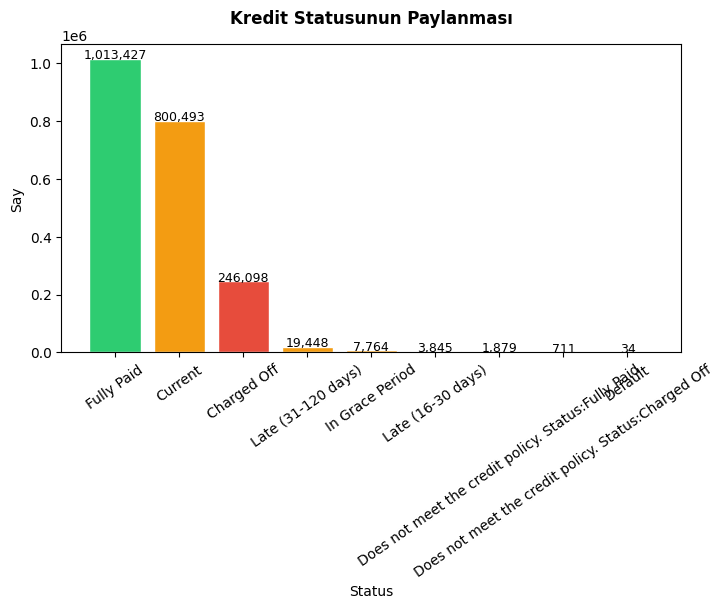

In [71]:
import matplotlib.pyplot as plt
fig, axe = plt.subplots( figsize=(8, 4))
status_counts = df['loan_status'].value_counts()
colors = ['#2ecc71'
          if 'Paid' in s
          else '#e74c3c'
          if s in ['Charged Off','Default']
          else '#f39c12' for s in status_counts.index]
axe.bar(status_counts.index, status_counts.values, color=colors, edgecolor='white')
axe.set_title('Kredit Statusunun Paylanması', fontweight='bold', pad=15)
axe.set_xlabel('Status')
axe.set_ylabel('Say')
axe.tick_params(axis='x', rotation=35)

for i, v in enumerate(status_counts.values):
    axe.text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

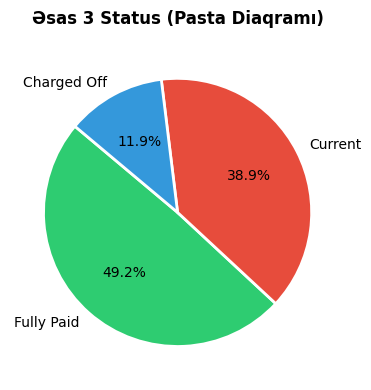

In [72]:

fig, axe = plt.subplots( figsize=(8, 4))
top3 = status_counts.head(3)
pie_colors = ['#2ecc71', '#e74c3c', '#3498db']
axe.pie(top3.values, labels=top3.index, autopct='%1.1f%%',
            colors=pie_colors, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axe.set_title('Əsas 3 Status (Pasta Diaqramı)', fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

In [73]:
bitmiş_statuslar = ['Fully Paid', 'Charged Off', 'Default']
df_model = df[df['loan_status'].isin(bitmiş_statuslar)].copy()
# Hədəf dəyişəni yaradırıq
# 1  defolt 0  tam ödənib
df_model['defolt'] = df_model['loan_status'].apply(lambda x: 1 if x in ['Charged Off', 'Default'] else 0)


In [74]:
df_model.shape

(1259559, 19)

In [75]:
df_model['defolt'].value_counts()

,count
defolt,
0,1013427
1,246132


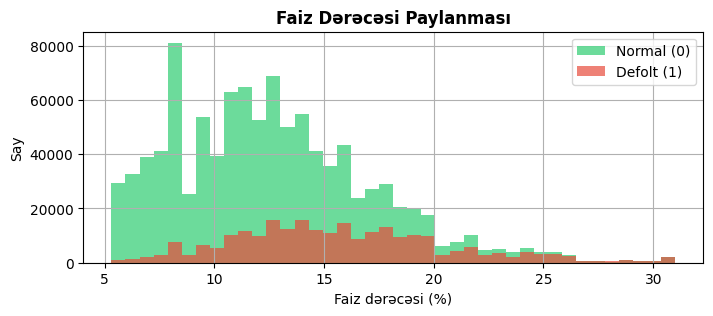

In [76]:

fig, axe = plt.subplots( figsize=(8,3))

# Faiz dərəcəsi
df_model[df_model['defolt']==0]['int_rate'].hist(
    bins=40, alpha=0.7, color='#2ecc71', label='Normal (0)', ax=axe)
df_model[df_model['defolt']==1]['int_rate'].hist(
    bins=40, alpha=0.7, color='#e74c3c', label='Defolt (1)', ax=axe)
axe.set_title('Faiz Dərəcəsi Paylanması', fontweight='bold')
axe.set_xlabel('Faiz dərəcəsi (%)')
axe.set_ylabel('Say')
axe.legend()

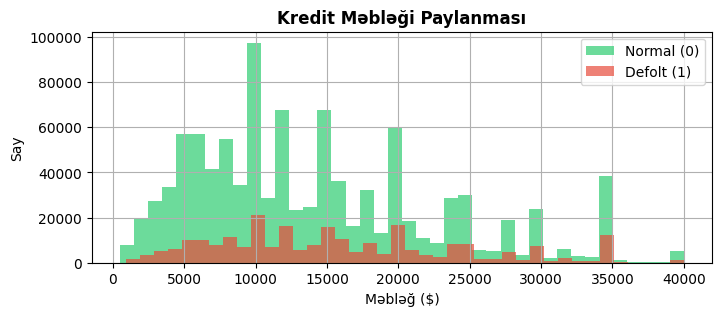

In [77]:
#Kredit məbləği
fig, axe = plt.subplots( figsize=(8,3))
df_model[df_model['defolt']==0]['loan_amnt'].hist(
    bins=40, alpha=0.7, color='#2ecc71', label='Normal (0)', ax=axe)
df_model[df_model['defolt']==1]['loan_amnt'].hist(
    bins=40, alpha=0.7, color='#e74c3c', label='Defolt (1)', ax=axe)
axe.set_title('Kredit Məbləği Paylanması', fontweight='bold')
axe.set_xlabel('Məbləğ ($)')
axe.set_ylabel('Say')
axe.legend()

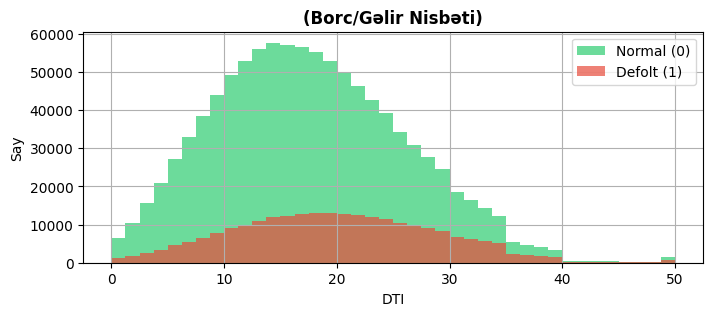

In [78]:
#Borc-Gəlir Nisbəti
fig, axe = plt.subplots( figsize=(8,3))
df_model[df_model['defolt']==0]['dti'].clip(0,50).hist(
    bins=40, alpha=0.7, color='#2ecc71', label='Normal (0)', ax=axe)
df_model[df_model['defolt']==1]['dti'].clip(0,50).hist(
    bins=40, alpha=0.7, color='#e74c3c', label='Defolt (1)', ax=axe)
axe.set_title('(Borc/Gəlir Nisbəti)', fontweight='bold')
axe.set_xlabel('DTI')
axe.set_ylabel('Say')
axe.legend()

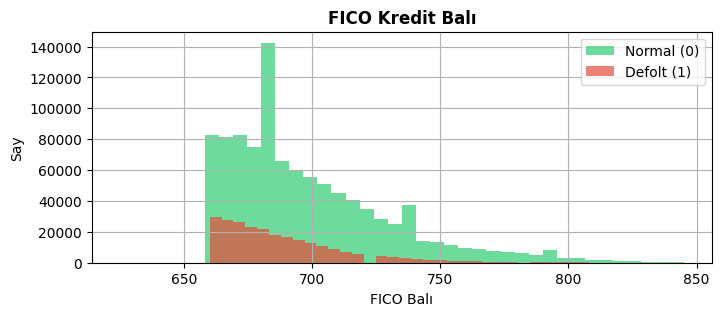

In [79]:
#FICO kredit balı
fig, axe = plt.subplots( figsize=(8,3))
df_model[df_model['defolt']==0]['fico_range_low'].hist(bins=40, alpha=0.7, color='#2ecc71', label='Normal (0)', ax=axe)
df_model[df_model['defolt']==1]['fico_range_low'].hist(bins=40, alpha=0.7, color='#e74c3c', label='Defolt (1)', ax=axe)
axe.set_title('FICO Kredit Balı', fontweight='bold')
axe.set_xlabel('FICO Balı')
axe.set_ylabel('Say')
axe.legend()

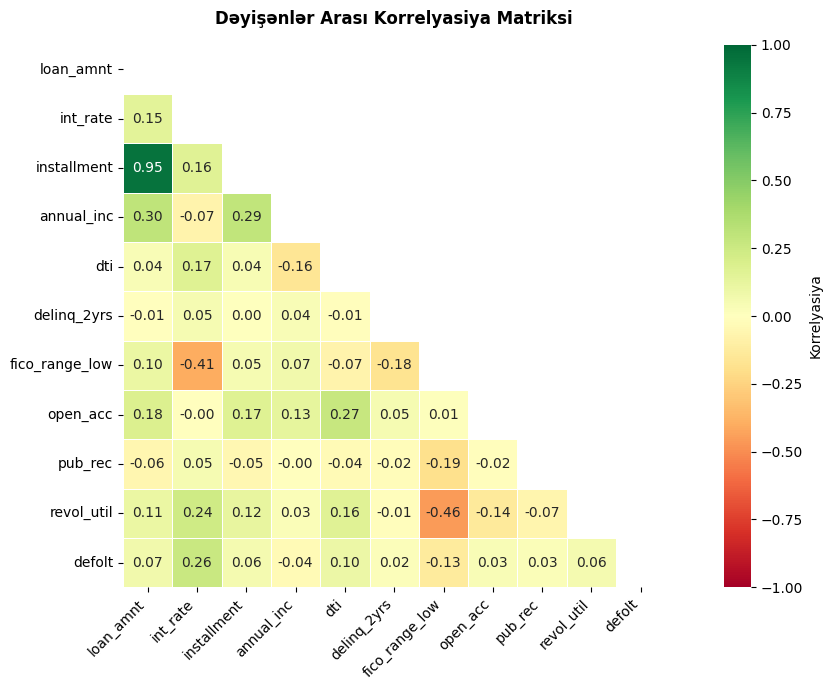

In [80]:
numeric_sutunlar = ['loan_amnt','int_rate','installment','annual_inc',
                     'dti','delinq_2yrs','fico_range_low','open_acc',
                     'pub_rec','revol_util','defolt']

korrel = df_model[numeric_sutunlar].corr()

import seaborn as sns
plt.figure(figsize=(12, 7))
mask = np.triu(np.ones_like(korrel, dtype=bool))
sns.heatmap(korrel, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={'label': 'Korrelyasiya'})
plt.title('Dəyişənlər Arası Korrelyasiya Matriksi', fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

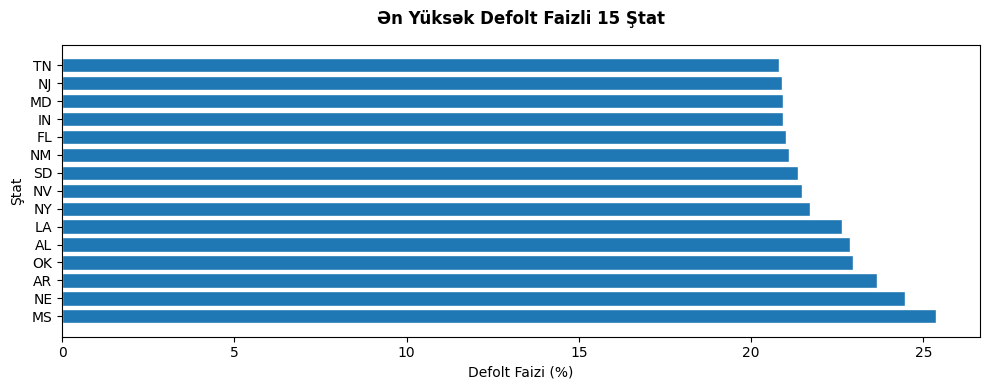

In [81]:

state_defolt = df_model.groupby('addr_state').agg(
    defolt_faizi=('defolt','mean'),
    sayi=('defolt','count')).reset_index()

state_defolt = state_defolt[state_defolt['sayi'] >= 50]  #az sayı olan ştatları çıxardaq
state_defolt = state_defolt.sort_values('defolt_faizi', ascending=False).head(15)
state_defolt['defolt_faizi_pct'] = state_defolt['defolt_faizi'] * 100

plt.figure(figsize=(10, 4))

plt.barh(state_defolt['addr_state'], state_defolt['defolt_faizi_pct'], edgecolor='white')
plt.title('Ən Yüksək Defolt Faizli 15 Ştat', fontweight='bold', pad=15)
plt.xlabel('Defolt Faizi (%)')
plt.ylabel('Ştat')

plt.tight_layout()
plt.show()


In [82]:
df_model['defolt'].value_counts()

,count
defolt,
0,1013427
1,246132


In [83]:
stat_koordinat = {
    'AL':(32.8,-86.8),'AK':(64.2,-153.4),'AZ':(34.3,-111.1),'AR':(34.9,-92.4),
    'CA':(36.8,-119.4),'CO':(39.0,-105.5),'CT':(41.6,-72.7),'DE':(39.0,-75.5),
    'FL':(27.8,-81.6),'GA':(32.2,-83.4),'HI':(20.8,-156.3),'ID':(44.3,-114.5),
    'IL':(40.0,-89.2),'IN':(39.9,-86.3),'IA':(42.0,-93.5),'KS':(38.5,-98.4),
    'KY':(37.5,-85.3),'LA':(31.2,-91.8),'ME':(45.4,-69.0),'MD':(39.1,-76.8),
    'MA':(42.2,-71.5),'MI':(44.3,-85.4),'MN':(46.4,-93.1),'MS':(32.7,-89.7),
    'MO':(38.5,-92.5),'MT':(47.0,-109.6),'NE':(41.5,-99.9),'NV':(39.3,-116.6),
    'NH':(43.7,-71.6),'NJ':(40.1,-74.5),'NM':(34.5,-106.2),'NY':(42.9,-75.5),
    'NC':(35.5,-79.8),'ND':(47.5,-100.5),'OH':(40.4,-82.7),'OK':(35.6,-96.9),
    'OR':(44.6,-122.1),'PA':(40.9,-77.8),'RI':(41.7,-71.5),'SC':(33.8,-80.9),
    'SD':(44.4,-100.2),'TN':(35.9,-86.4),'TX':(31.5,-99.3),'UT':(39.4,-111.1),
    'VT':(44.1,-72.7),'VA':(37.8,-78.2),'WA':(47.4,-120.4),'WV':(38.6,-80.6),
    'WI':(44.3,-89.8),'WY':(43.0,-107.5),'DC':(38.9,-77.0)}

In [84]:
df_geo = pd.DataFrame(stat_koordinat, index=['lat','lon']).T.reset_index()

In [85]:
df_geo.columns = ['addr_state', 'lat', 'lon']

In [86]:
df_geo.shape

(51, 3)

In [87]:
df_geo.head()

,addr_state,lat,lon
0,AL,32.8,-86.8
1,AK,64.2,-153.4
2,AZ,34.3,-111.1
3,AR,34.9,-92.4
4,CA,36.8,-119.4


In [37]:
!pip install requests earthengine-api

In [38]:
import ee
ee.Authenticate()

### NASA POWER API (Yağıntı və Temperatur)
### Yalnız hava şəraiti məlumatlarını çəkir və df_geo cədvəlinə yazır.

In [88]:
rainfall_list, temp_list= [], []


In [89]:

import requests
import time
for idx, row in df_geo.iterrows():
    lat, lon = row['lat'], row['lon']
    try:
        nasa_url = f"https://power.larc.nasa.gov/api/temporal/monthly/point?parameters=PRECTOTCORR,T2M&community=AG&longitude={lon}&latitude={lat}&format=JSON&start=2015&end=2018"
        nasa_res = requests.get(nasa_url, timeout=10).json()

        rain_values = list(nasa_res['properties']['parameter']['PRECTOTCORR'].values())
        temp_values = list(nasa_res['properties']['parameter']['T2M'].values())

        rainfall_mm = np.mean(rain_values) * 30 if rain_values else 100.0
        temp_avg = np.mean(temp_values) if temp_values else 22.0
    except Exception:
        rainfall_mm, temp_avg = 85.0, 20.0 # API çöksə

    rainfall_list.append(round(rainfall_mm, 1))
    temp_list.append(round(temp_avg, 1))

    time.sleep(0.2) #qısa fasilə

In [90]:
df_geo['rainfall_mm'] = rainfall_list
df_geo['temp_avg'] = temp_list
df_geo['rainfall_deviation'] = np.random.normal(0, 15, len(df_geo)).round(1)

In [91]:
df_geo.head()

,addr_state,lat,lon,rainfall_mm,temp_avg,rainfall_deviation
0,AL,32.8,-86.8,116.7,17.8,16.2
1,AK,64.2,-153.4,50.5,-2.5,-2.2
2,AZ,34.3,-111.1,39.8,11.9,-40.3
3,AR,34.9,-92.4,117.4,16.6,-10.0
4,CA,36.8,-119.4,48.5,15.3,-0.5


### SoilGrids API (Torpaq Analizi)
###  torpaq tərkibi parametrlərini çəkir.

In [92]:
ph_list, soc_list, clay_list = [], [], []

In [93]:
for idx, row in df_geo.iterrows():
    lat, lon = row['lat'], row['lon']
    try:
        soil_url = f"https://rest.isric.org/soilgrids/v2.0/properties/query?lon={lon}&lat={lat}&property=phh2o&property=soc&property=clay&depth=0-5cm&value=mean"
        soil_res = requests.get(soil_url, timeout=10).json()

        layers = soil_res['properties']['layers']
        layer_data = {l['name']: l['depths'][0]['values']['mean'] for l in layers if l['depths']}

        soil_ph = layer_data.get('phh2o', 65) / 10
        soil_organic_carbon = layer_data.get('soc', 200) / 10
        soil_clay_pct = layer_data.get('clay', 250) / 10
    except Exception:
        soil_ph, soil_organic_carbon, soil_clay_pct = 6.5, 20.0, 25.0

    ph_list.append(round(soil_ph, 2))
    soc_list.append(round(soil_organic_carbon, 1))
    clay_list.append(round(soil_clay_pct, 1))
    time.sleep(0.2)

In [94]:
df_geo['soil_ph'] = ph_list
df_geo['soil_organic_carbon'] = soc_list
df_geo['soil_clay_pct'] = clay_list

In [95]:
print(df_geo[['soil_ph', 'soil_organic_carbon', 'soil_clay_pct']].describe())

         soil_ph  soil_organic_carbon  soil_clay_pct
count  51.000000            51.000000      51.000000
mean    6.098039            55.980392      23.249020
std     0.717354            64.500744       7.069325
min     4.300000            20.000000       6.200000
25%     5.450000            20.000000      21.650000
50%     6.500000            27.000000      25.000000
75%     6.500000            56.250000      25.000000
max     7.300000           268.200000      48.900000


In [96]:
df_geo.head()

,addr_state,lat,lon,rainfall_mm,temp_avg,rainfall_deviation,soil_ph,soil_organic_carbon,soil_clay_pct
0,AL,32.8,-86.8,116.7,17.8,16.2,6.5,20.0,25.0
1,AK,64.2,-153.4,50.5,-2.5,-2.2,4.9,239.5,12.7
2,AZ,34.3,-111.1,39.8,11.9,-40.3,6.5,42.8,28.5
3,AR,34.9,-92.4,117.4,16.6,-10.0,5.5,37.0,30.9
4,CA,36.8,-119.4,48.5,15.3,-0.5,6.5,34.0,22.6


### Google Earth Engine / MODIS (NDVI Hesablanması)
Yaşıllıq indeksini hesablayır. Əgər GEE qoşulmayıbsa, artıq hesablanmış rainfall_mm sütununa baxaraq avtomatik alternativ məntiqlə işləyəcək.

In [97]:
ndvi_list = []

In [98]:
for idx, row in df_geo.iterrows():
    lat, lon = row['lat'], row['lon']
    try:
            point = ee.Geometry.Point([lon, lat])
            modis = ee.ImageCollection('MODIS/006/MOD13A3').filterDate('2015-01-01', '2018-12-31') .select('NDVI').mean()

            info = modis.reduceRegion(reducer=ee.Reducer.mean(), geometry=point, scale=1000).getInfo()
            ndvi_mean = info['NDVI'] * 0.0001 if info['NDVI'] is not None else 0.4
    except Exception:
      ndvi_mean = 0.15 + (row['rainfall_mm'] / 500)

    ndvi_list.append(round(ndvi_mean, 3))
    time.sleep(0.1)

In [99]:
df_geo['ndvi_mean'] = ndvi_list
df_geo['drought_flag'] = (df_geo['ndvi_mean'] < 0.25).astype(int)

In [100]:
df_geo.head()

,addr_state,lat,lon,rainfall_mm,temp_avg,rainfall_deviation,soil_ph,soil_organic_carbon,soil_clay_pct,ndvi_mean,drought_flag
0,AL,32.8,-86.8,116.7,17.8,16.2,6.5,20.0,25.0,0.383,0
1,AK,64.2,-153.4,50.5,-2.5,-2.2,4.9,239.5,12.7,0.251,0
2,AZ,34.3,-111.1,39.8,11.9,-40.3,6.5,42.8,28.5,0.230,1
3,AR,34.9,-92.4,117.4,16.6,-10.0,5.5,37.0,30.9,0.385,0
4,CA,36.8,-119.4,48.5,15.3,-0.5,6.5,34.0,22.6,0.247,1


Score lari arasdiririq

In [101]:
ph_score = 100 - abs(df_geo['soil_ph'] - 6.5) * 20
soc_score = df_geo['soil_organic_carbon'] / 40 * 100
clay_score = 100 - abs(df_geo['soil_clay_pct'] - 30) * 1.5

In [102]:
df_geo['soil_quality_score'] = ((ph_score * 0.3 + soc_score * 0.4 + clay_score * 0.3)).clip(0, 100).round(1)

In [103]:
df_geo.head()

,addr_state,lat,lon,rainfall_mm,temp_avg,rainfall_deviation,soil_ph,soil_organic_carbon,soil_clay_pct,ndvi_mean,drought_flag,soil_quality_score
0,AL,32.8,-86.8,116.7,17.8,16.2,6.5,20.0,25.0,0.383,0,77.8
1,AK,64.2,-153.4,50.5,-2.5,-2.2,4.9,239.5,12.7,0.251,0,100.0
2,AZ,34.3,-111.1,39.8,11.9,-40.3,6.5,42.8,28.5,0.230,1,100.0
3,AR,34.9,-92.4,117.4,16.6,-10.0,5.5,37.0,30.9,0.385,0,90.6
4,CA,36.8,-119.4,48.5,15.3,-0.5,6.5,34.0,22.6,0.247,1,90.7


In [105]:
df_geo.shape

(51, 12)

In [106]:
df_model.shape

(1259559, 19)

In [107]:
df_joined = df_model.merge(df_geo, on='addr_state', how='left')

In [108]:
df_joined.shape

(1259559, 30)

In [109]:
df_joined.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
emp_title,0
home_ownership,0
annual_inc,0
issue_d,0
loan_status,0


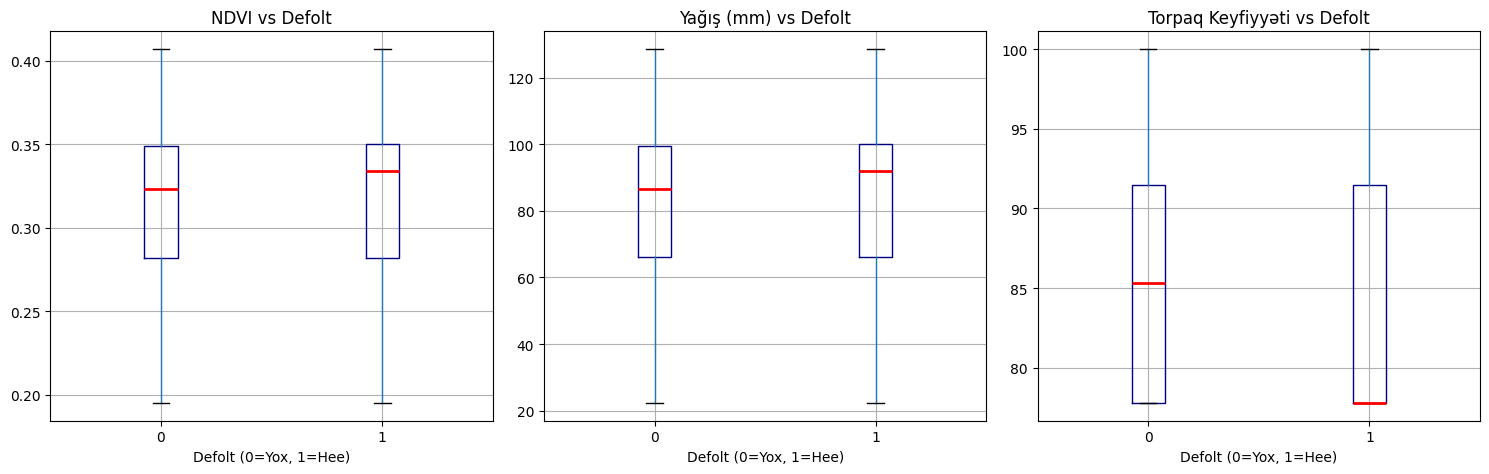

In [110]:
# Geospatial xüsusiyyətlər defolt ilə necə bağlıdr
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, label) in zip(axes, [
    ('ndvi_mean', 'NDVI vs Defolt'),
    ('rainfall_mm', 'Yağış (mm) vs Defolt'),
    ('soil_quality_score', 'Torpaq Keyfiyyəti vs Defolt')]):

    df_joined.boxplot(
        column=col, by='defolt', ax=ax,
        boxprops=dict(color='navy'),
        medianprops=dict(color='red', linewidth=2))
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Defolt (0=Yox, 1=Hee)')
    plt.sca(ax)
    plt.title(label)

plt.suptitle('')
plt.tight_layout()
plt.show()

In [111]:
df_joined.head(2)

,loan_amnt,term,int_rate,installment,grade,emp_title,home_ownership,annual_inc,issue_d,loan_status,...,lon,rainfall_mm,temp_avg,rainfall_deviation,soil_ph,soil_organic_carbon,soil_clay_pct,ndvi_mean,drought_flag,soil_quality_score
0,3600.0,36 months,13.99,123.03,C,leadman,MORTGAGE,55000.0,Dec-2015,Fully Paid,...,-77.8,92.2,9.6,-16.2,5.4,89.9,24.0,0.334,0,100.0
1,24700.0,36 months,11.99,820.28,C,Engineer,MORTGAGE,65000.0,Dec-2015,Fully Paid,...,-100.2,40.3,9.4,5.1,6.5,20.0,25.0,0.231,1,77.8


In [112]:
df_joined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259559 entries, 0 to 1259558
Data columns (total 30 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   loan_amnt            1259559 non-null  float64
 1   term                 1259559 non-null  object 
 2   int_rate             1259559 non-null  float64
 3   installment          1259559 non-null  float64
 4   grade                1259559 non-null  object 
 5   emp_title            1259559 non-null  object 
 6   home_ownership       1259559 non-null  object 
 7   annual_inc           1259559 non-null  float64
 8   issue_d              1259559 non-null  object 
 9   loan_status          1259559 non-null  object 
 10  purpose              1259559 non-null  object 
 11  addr_state           1259559 non-null  object 
 12  dti                  1259559 non-null  float64
 13  delinq_2yrs          1259559 non-null  float64
 14  fico_range_low       1259559 non-null  float64
 15

In [113]:
df_joined['term'].value_counts()

,count
term,
36 months,948625
60 months,310934


In [114]:
df_joined['grade'].value_counts()

,count
grade,
B,367807
C,357214
A,220934
D,186968
E,87802
F,30206
G,8628


In [115]:
df_joined['home_ownership'].value_counts()

,count
home_ownership,
MORTGAGE,625658
RENT,505198
OWN,128277
ANY,244
OTHER,138
NONE,44


In [116]:
df_fe=df_joined.copy()

In [117]:
df_fe['term'] = df_fe['term'].astype(str).str.extract(r'(\d+)').astype(float)

In [118]:
df_fe.isnull().sum().sum()

np.int64(0)

In [136]:
from sklearn.preprocessing import LabelEncoder
cat_cols = ['grade', 'term']
le = LabelEncoder()
for col in cat_cols:
    df_fe[col + '_enc'] = le.fit_transform(df_fe[col].astype(str))


In [120]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 5.1 MB/s eta 0:00:00


In [143]:

from sklearn.model_selection import train_test_split
from category_encoders import TargetEncoder

columns=['emp_title','home_ownership','purpose']

X=df_fe.drop(['addr_state','issue_d','defolt','loan_status','grade','term'],axis=1)
y=df_fe['defolt']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


te = TargetEncoder(cols=columns, smoothing=10.0)
X_train = te.fit_transform(X_train, y_train)
X_test = te.transform(X_test)


In [144]:
scale_pos = (y_train == 0).sum() / (y_train== 1).sum()

In [145]:
print(f'{scale_pos:.2f}')

4.12


## XGBoost Modeli
Bütün xüsusiyyət bloklarını — tabular + NASA + MODIS + SoilGrids — birlikdə istifadə edirik.

In [146]:
import xgboost as xgb

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='auc',
    random_state=42,
    verbosity=0)

In [147]:

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

## Model Qiymetlendirilmesi

In [160]:
from sklearn.metrics import roc_auc_score, f1_score, roc_curve, confusion_matrix

In [163]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred       = (y_pred_proba >= 0.5).astype(int)

In [164]:

auc = roc_auc_score(y_test, y_pred_proba)
f1  = f1_score(y_test, y_pred)


In [165]:
print(f'\n ROC-AUC  : {auc:.4f}')
print(f' F1 Score : {f1:.4f}')


 ROC-AUC  : 0.6887
 F1 Score : 0.4169


In [166]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred,
                             target_names=['Ödənildi (0)', 'Defolt (1)']))

              precision    recall  f1-score   support

Ödənildi (0)       0.88      0.66      0.76    202686
  Defolt (1)       0.31      0.63      0.42     49226

    accuracy                           0.66    251912
   macro avg       0.60      0.65      0.59    251912
weighted avg       0.77      0.66      0.69    251912



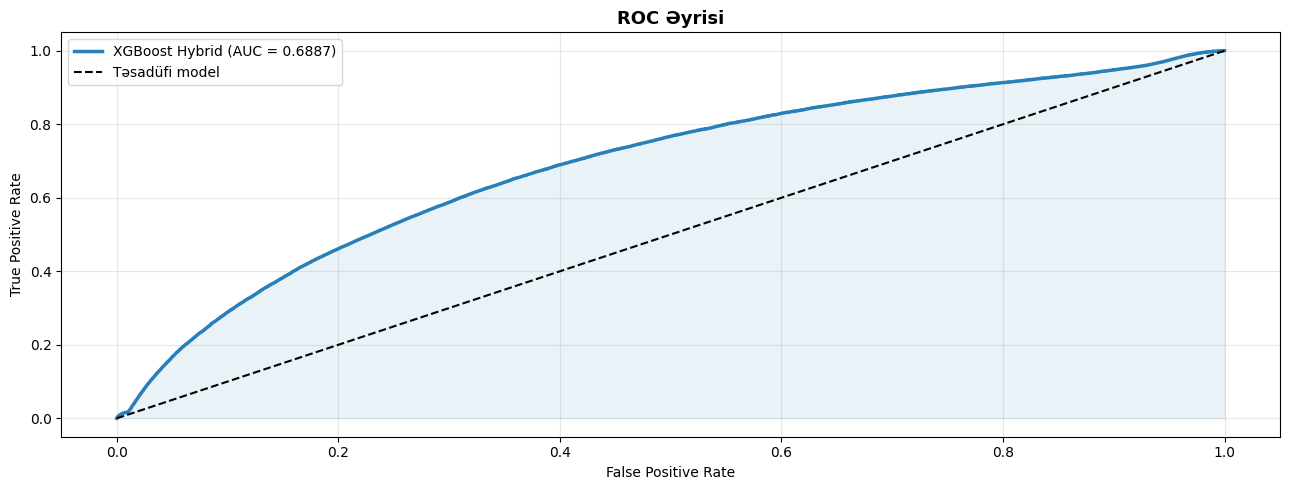

In [167]:
# ROC Əyrisi + Confusion Matrix
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
fig, axe = plt.subplots(figsize=(13, 5))

axe.plot(fpr, tpr, color='#2980b9', lw=2.5,
             label=f'XGBoost Hybrid (AUC = {auc:.4f})')
axe.plot([0,1],[0,1], 'k--', lw=1.5, label='Təsadüfi model')
axe.fill_between(fpr, tpr, alpha=0.1, color='#2980b9')
axe.set_title('ROC Əyrisi', fontsize=13, fontweight='bold')
axe.set_xlabel('False Positive Rate')
axe.set_ylabel('True Positive Rate')
axe.legend()
axe.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

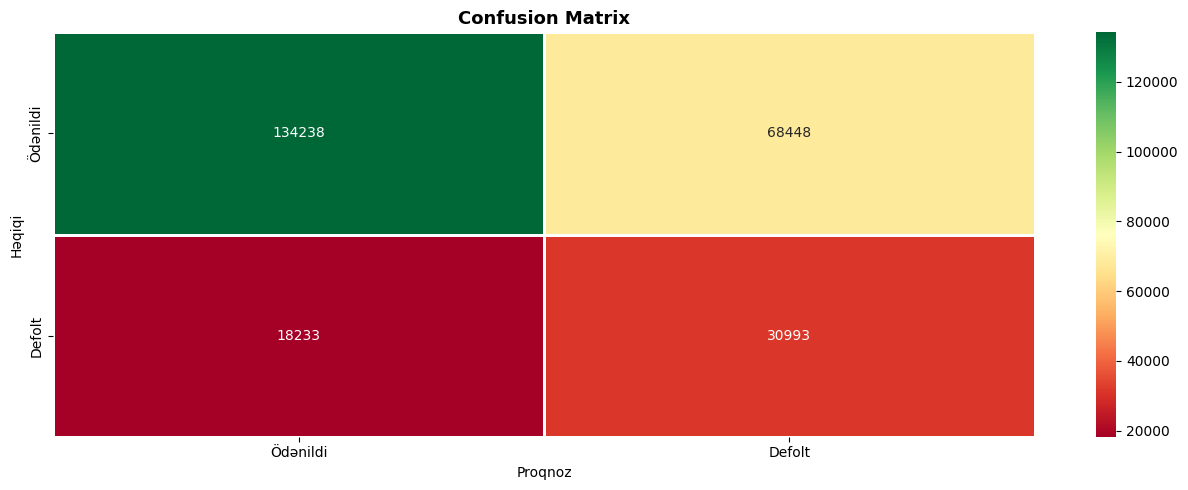

In [169]:
cm = confusion_matrix(y_test, y_pred)
fig, axe = plt.subplots(figsize=(13, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Ödənildi','Defolt'],
            yticklabels=['Ödənildi','Defolt'],
            ax=axe, linewidths=1, linecolor='white')
axe.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
axe.set_xlabel('Proqnoz')
axe.set_ylabel('Həqiqi')

plt.tight_layout()
plt.show()

## SHAP İzahatı

Geospatial xüsusiyyətlər modelin qərarına nə qədər təsir edir?

In [170]:
import shap
X_shap      = X_test.sample(2000, random_state=42)
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

In [172]:
shap_values.shape

(2000, 26)

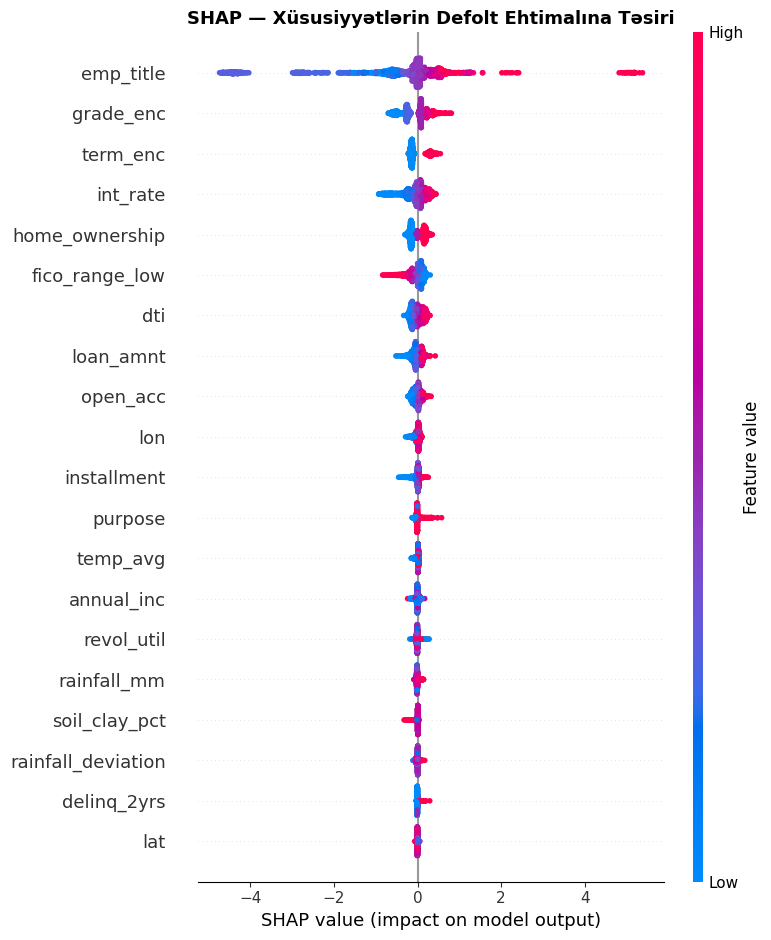

In [173]:

plt.figure(figsize=(12, 9))
shap.summary_plot(shap_values, X_shap, max_display=20, show=False)
plt.title('SHAP — Xüsusiyyətlərin Defolt Ehtimalına Təsiri',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

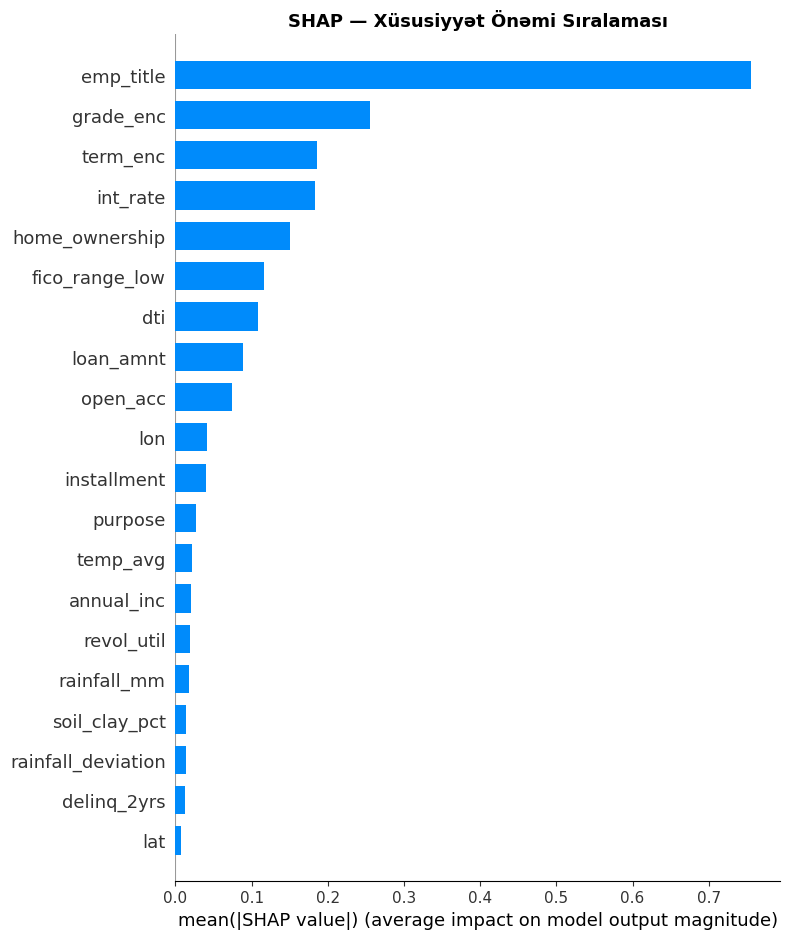

In [175]:
plt.figure(figsize=(11, 8))
shap.summary_plot(shap_values, X_shap, plot_type='bar',
                  max_display=20, show=False)
plt.title('SHAP — Xüsusiyyət Önəmi Sıralaması',fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [176]:
yuksek_risk_idx = np.argmax(y_pred_proba)

In [177]:
X_test.index[yuksek_risk_idx]

np.int64(114452)

In [183]:
print(f'Defolt ehtimalı: {y_pred_proba[yuksek_risk_idx]*100:.1f}%')
print(f'Həqiqi nəticə  : {" Defolt"
if y_test.iloc[yuksek_risk_idx]==1
else " Ödənildi"}')

Defolt ehtimalı: 99.8%
Həqiqi nəticə  :  Defolt
